# Push-Up Feature Engineering

This notebook computes frame-level and video-level features from MediaPipe pose landmarks.

It extracts joint angles and body alignment measures, applies temporal smoothing,
and aggregates them into features used for rule-based evaluation and ML models.

The output of this notebook is used in notebooks 03 (development pipeline)
and 04 (final comparison and model selection).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.signal import savgol_filter

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

LANDMARKS_CSV_PATH = INTERIM_DIR / "pose_landmarks_pushups.csv"
FEATURES_CSV_PATH = PROCESSED_DIR / "pushup_features.csv"

pose_df = pd.read_csv(LANDMARKS_CSV_PATH)

print("Loaded shape:", pose_df.shape)
print("Columns:", len(pose_df.columns))
pose_df.head()

Loaded shape: (10928, 139)
Columns: 139


,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,right_heel_visibility,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility,pose_detected
0,Copy of push up 1.mp4,Copy of push up 1,correct,0,25.0,0.00,0.737741,0.611303,0.014359,0.999858,...,0.987817,0.115150,0.906979,0.291378,0.866467,0.104528,0.931178,0.032273,0.987492,1
1,Copy of push up 1.mp4,Copy of push up 1,correct,1,25.0,0.04,0.724616,0.607699,0.011920,0.999796,...,0.986590,0.114344,0.906850,0.230542,0.847561,0.104248,0.931257,-0.039504,0.985982,1
2,Copy of push up 1.mp4,Copy of push up 1,correct,2,25.0,0.08,0.720977,0.606046,0.011736,0.999764,...,0.985962,0.113232,0.906629,0.224317,0.833872,0.103429,0.931365,-0.039549,0.985207,1
3,Copy of push up 1.mp4,Copy of push up 1,correct,3,25.0,0.12,0.721067,0.605006,0.013029,0.999734,...,0.985171,0.112770,0.905566,0.217476,0.818031,0.103047,0.931322,-0.051117,0.984212,1
4,Copy of push up 1.mp4,Copy of push up 1,correct,4,25.0,0.16,0.721958,0.604109,0.012018,0.999715,...,0.984401,0.109374,0.904433,0.199174,0.803506,0.101249,0.931254,-0.069340,0.983280,1


In [3]:
print("Number of videos:", pose_df["video_name"].nunique())
print("Labels:", pose_df["label"].value_counts().to_dict())
print("Pose detected ratio:", pose_df["pose_detected"].mean())

pose_df[["video_name", "label", "frame_index"]].head()

Number of videos: 100
Labels: {'incorrect': 6425, 'correct': 4503}
Pose detected ratio: 0.9999084919472914


,video_name,label,frame_index
0,Copy of push up 1.mp4,correct,0
1,Copy of push up 1.mp4,correct,1
2,Copy of push up 1.mp4,correct,2
3,Copy of push up 1.mp4,correct,3
4,Copy of push up 1.mp4,correct,4


In [4]:
def safe_norm(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return n if n > 1e-8 else np.nan


def compute_angle_2d(a, b, c):
    """
    Computes angle ABC in degrees using x and y only.
    """
    a = np.array(a[:2], dtype=float)
    b = np.array(b[:2], dtype=float)
    c = np.array(c[:2], dtype=float)
    
    ba = a - b
    bc = c - b
    
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    
    if norm_ba < 1e-8 or norm_bc < 1e-8:
        return np.nan
    
    cosine = np.dot(ba, bc) / (norm_ba * norm_bc)
    cosine = np.clip(cosine, -1.0, 1.0)
    return np.degrees(np.arccos(cosine))


def compute_angle_3d(a, b, c):
    """
    Computes angle ABC in degrees using x, y, z.
    """
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)
    
    ba = a - b
    bc = c - b
    
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    
    if norm_ba < 1e-8 or norm_bc < 1e-8:
        return np.nan
    
    cosine = np.dot(ba, bc) / (norm_ba * norm_bc)
    cosine = np.clip(cosine, -1.0, 1.0)
    return np.degrees(np.arccos(cosine))


def get_point(row, side, joint, dims="xyz"):
    values = []
    for d in dims:
        values.append(row[f"{side}_{joint}_{d}"])
    return values


def get_visibility(row, side, joints):
    vals = [row[f"{side}_{joint}_visibility"] for joint in joints]
    vals = [v for v in vals if pd.notna(v)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))


def euclidean_distance_2d(p1, p2):
    p1 = np.array(p1[:2], dtype=float)
    p2 = np.array(p2[:2], dtype=float)
    return np.linalg.norm(p1 - p2)


def euclidean_distance_3d(p1, p2):
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    return np.linalg.norm(p1 - p2)

In [5]:
def choose_body_side(row):
    """
    Selects the more reliable side based on average landmark visibility.
    For push-ups, the most important chain is shoulder-elbow-wrist-hip-knee-ankle.
    """
    key_joints = ["shoulder", "elbow", "wrist", "hip", "knee", "ankle"]
    
    left_score = get_visibility(row, "left", key_joints)
    right_score = get_visibility(row, "right", key_joints)
    
    if pd.isna(left_score) and pd.isna(right_score):
        return "left"
    if pd.isna(right_score):
        return "left"
    if pd.isna(left_score):
        return "right"
    
    return "left" if left_score >= right_score else "right"

In [6]:
def extract_pushup_features(row):
    side = choose_body_side(row)
    
    shoulder_3d = get_point(row, side, "shoulder", dims="xyz")
    elbow_3d = get_point(row, side, "elbow", dims="xyz")
    wrist_3d = get_point(row, side, "wrist", dims="xyz")
    hip_3d = get_point(row, side, "hip", dims="xyz")
    knee_3d = get_point(row, side, "knee", dims="xyz")
    ankle_3d = get_point(row, side, "ankle", dims="xyz")
    
    shoulder_2d = shoulder_3d[:2]
    elbow_2d = elbow_3d[:2]
    wrist_2d = wrist_3d[:2]
    hip_2d = hip_3d[:2]
    knee_2d = knee_3d[:2]
    ankle_2d = ankle_3d[:2]
    
    elbow_angle_2d = compute_angle_2d(shoulder_2d, elbow_2d, wrist_2d)
    elbow_angle_3d = compute_angle_3d(shoulder_3d, elbow_3d, wrist_3d)
    
    body_alignment_angle_2d = compute_angle_2d(shoulder_2d, hip_2d, ankle_2d)
    body_alignment_angle_3d = compute_angle_3d(shoulder_3d, hip_3d, ankle_3d)
    
    hip_angle_2d = compute_angle_2d(shoulder_2d, hip_2d, knee_2d)
    hip_angle_3d = compute_angle_3d(shoulder_3d, hip_3d, knee_3d)
    
    knee_angle_2d = compute_angle_2d(hip_2d, knee_2d, ankle_2d)
    knee_angle_3d = compute_angle_3d(hip_3d, knee_3d, ankle_3d)
    
    shoulder_wrist_dist_2d = euclidean_distance_2d(shoulder_2d, wrist_2d)
    shoulder_wrist_dist_3d = euclidean_distance_3d(shoulder_3d, wrist_3d)
    
    hip_ankle_dist_2d = euclidean_distance_2d(hip_2d, ankle_2d)
    hip_ankle_dist_3d = euclidean_distance_3d(hip_3d, ankle_3d)
    
    shoulder_hip_dist_2d = euclidean_distance_2d(shoulder_2d, hip_2d)
    shoulder_hip_dist_3d = euclidean_distance_3d(shoulder_3d, hip_3d)
    
    elbow_wrist_dist_2d = euclidean_distance_2d(elbow_2d, wrist_2d)
    elbow_wrist_dist_3d = euclidean_distance_3d(elbow_3d, wrist_3d)
    
    upper_arm_length_2d = euclidean_distance_2d(shoulder_2d, elbow_2d)
    upper_arm_length_3d = euclidean_distance_3d(shoulder_3d, elbow_3d)
    
    torso_leg_ratio_2d = shoulder_hip_dist_2d / hip_ankle_dist_2d if hip_ankle_dist_2d > 1e-8 else np.nan
    torso_leg_ratio_3d = shoulder_hip_dist_3d / hip_ankle_dist_3d if hip_ankle_dist_3d > 1e-8 else np.nan
    
    return pd.Series({
        "selected_side": side,
        "side_visibility_score": get_visibility(row, side, ["shoulder", "elbow", "wrist", "hip", "knee", "ankle"]),
        
        "elbow_angle_2d": elbow_angle_2d,
        "elbow_angle_3d": elbow_angle_3d,
        
        "body_alignment_angle_2d": body_alignment_angle_2d,
        "body_alignment_angle_3d": body_alignment_angle_3d,
        
        "hip_angle_2d": hip_angle_2d,
        "hip_angle_3d": hip_angle_3d,
        
        "knee_angle_2d": knee_angle_2d,
        "knee_angle_3d": knee_angle_3d,
        
        "shoulder_wrist_dist_2d": shoulder_wrist_dist_2d,
        "shoulder_wrist_dist_3d": shoulder_wrist_dist_3d,
        
        "hip_ankle_dist_2d": hip_ankle_dist_2d,
        "hip_ankle_dist_3d": hip_ankle_dist_3d,
        
        "shoulder_hip_dist_2d": shoulder_hip_dist_2d,
        "shoulder_hip_dist_3d": shoulder_hip_dist_3d,
        
        "elbow_wrist_dist_2d": elbow_wrist_dist_2d,
        "elbow_wrist_dist_3d": elbow_wrist_dist_3d,
        
        "upper_arm_length_2d": upper_arm_length_2d,
        "upper_arm_length_3d": upper_arm_length_3d,
        
        "torso_leg_ratio_2d": torso_leg_ratio_2d,
        "torso_leg_ratio_3d": torso_leg_ratio_3d,
    })

In [7]:
feature_df = pose_df.copy()
derived_features = feature_df.apply(extract_pushup_features, axis=1)
feature_df = pd.concat([feature_df, derived_features], axis=1)

print("Feature dataset shape:", feature_df.shape)
feature_df.head()

Feature dataset shape: (10928, 161)


,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,hip_ankle_dist_2d,hip_ankle_dist_3d,shoulder_hip_dist_2d,shoulder_hip_dist_3d,elbow_wrist_dist_2d,elbow_wrist_dist_3d,upper_arm_length_2d,upper_arm_length_3d,torso_leg_ratio_2d,torso_leg_ratio_3d
0,Copy of push up 1.mp4,Copy of push up 1,correct,0,25.0,0.00,0.737741,0.611303,0.014359,0.999858,...,0.437784,0.492225,0.271822,0.279189,0.234588,0.242689,0.277246,0.281462,0.620905,0.567197
1,Copy of push up 1.mp4,Copy of push up 1,correct,1,25.0,0.04,0.724616,0.607699,0.011920,0.999796,...,0.436670,0.467095,0.268450,0.274493,0.233598,0.238412,0.272276,0.277548,0.614767,0.587661
2,Copy of push up 1.mp4,Copy of push up 1,correct,2,25.0,0.08,0.720977,0.606046,0.011736,0.999764,...,0.435494,0.465799,0.267200,0.272610,0.231657,0.236564,0.269154,0.274837,0.613557,0.585252
3,Copy of push up 1.mp4,Copy of push up 1,correct,3,25.0,0.12,0.721067,0.605006,0.013029,0.999734,...,0.434744,0.462328,0.266276,0.270988,0.230343,0.235145,0.265843,0.271928,0.612489,0.586137
4,Copy of push up 1.mp4,Copy of push up 1,correct,4,25.0,0.16,0.721958,0.604109,0.012018,0.999715,...,0.436896,0.460813,0.264904,0.269483,0.230612,0.234278,0.265772,0.272779,0.606332,0.584800


In [8]:
feature_nan_ratio = feature_df.isna().mean().sort_values(ascending=False)
feature_nan_ratio.head(30)

right_pinky_z             0.000092
left_knee_visibility      0.000092
right_hip_x               0.000092
right_hip_y               0.000092
right_hip_z               0.000092
right_hip_visibility      0.000092
left_knee_x               0.000092
left_knee_y               0.000092
left_knee_z               0.000092
right_knee_x              0.000092
left_hip_z                0.000092
right_knee_y              0.000092
right_knee_z              0.000092
right_knee_visibility     0.000092
left_ankle_x              0.000092
left_ankle_y              0.000092
left_ankle_z              0.000092
left_ankle_visibility     0.000092
left_hip_visibility       0.000092
left_hip_y                0.000092
right_ankle_y             0.000092
right_index_visibility    0.000092
left_index_x              0.000092
left_index_y              0.000092
left_index_z              0.000092
left_index_visibility     0.000092
right_index_x             0.000092
right_index_y             0.000092
right_index_z       

In [9]:
def smooth_series(values, window_length=11, polyorder=2):
    values = pd.Series(values).astype(float)
    
    if values.notna().sum() < window_length:
        return values.copy()
    
    filled = values.interpolate(limit_direction="both")
    
    if filled.isna().all():
        return values.copy()
    
    wl = min(window_length, len(filled))
    
    if wl % 2 == 0:
        wl -= 1
    
    if wl < 3:
        return filled
    
    po = min(polyorder, wl - 1)
    
    try:
        smoothed = savgol_filter(filled.values, window_length=wl, polyorder=po)
        return pd.Series(smoothed, index=values.index)
    except Exception:
        return filled

In [10]:
feature_df = feature_df.sort_values(["video_name", "frame_index"]).reset_index(drop=True)

signals_to_smooth = [
    "elbow_angle_2d",
    "elbow_angle_3d",
    "body_alignment_angle_2d",
    "body_alignment_angle_3d",
    "hip_angle_2d",
    "hip_angle_3d",
    "knee_angle_2d",
    "knee_angle_3d"
]

for signal in signals_to_smooth:
    feature_df[f"{signal}_smooth"] = (
        feature_df.groupby("video_name")[signal]
        .transform(lambda s: smooth_series(s, window_length=11, polyorder=2))
    )

print("Smoothing complete.")
feature_df.head()

Smoothing complete.


,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,torso_leg_ratio_2d,torso_leg_ratio_3d,elbow_angle_2d_smooth,elbow_angle_3d_smooth,body_alignment_angle_2d_smooth,body_alignment_angle_3d_smooth,hip_angle_2d_smooth,hip_angle_3d_smooth,knee_angle_2d_smooth,knee_angle_3d_smooth
0,1.mp4,1,incorrect,0,29.97,0.000000,0.639666,0.368928,-0.058671,0.999208,...,0.687331,0.730316,171.943379,141.455281,176.481196,170.344146,166.108025,153.346879,156.900532,143.099334
1,1.mp4,1,incorrect,1,29.97,0.033367,0.639678,0.368796,-0.055482,0.999269,...,0.697079,0.728861,171.861359,141.943433,177.336497,169.818622,167.188835,155.121383,155.920440,145.340742
2,1.mp4,1,incorrect,2,29.97,0.066733,0.639597,0.368087,-0.048250,0.999331,...,0.703534,0.733967,171.781156,142.392270,178.023783,169.320917,168.116391,156.588858,155.117997,147.245973
3,1.mp4,1,incorrect,3,29.97,0.100100,0.639678,0.367229,-0.046277,0.999389,...,0.706282,0.730910,171.702770,142.801792,178.543055,168.851033,168.890693,157.749305,154.493203,148.815027
4,1.mp4,1,incorrect,4,29.97,0.133467,0.639661,0.365993,-0.047264,0.999439,...,0.706987,0.738580,171.626201,143.171999,178.894313,168.408969,169.511741,158.602723,154.046059,150.047903


In [12]:
temporal_signals = [
    "elbow_angle_3d_smooth",
    "body_alignment_angle_3d_smooth",
    "hip_angle_3d_smooth"
]

for signal in temporal_signals:
    feature_df[f"{signal}_diff"] = (
        feature_df.groupby("video_name")[signal]
        .diff()
    )

feature_df.head()

,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,elbow_angle_3d_smooth,body_alignment_angle_2d_smooth,body_alignment_angle_3d_smooth,hip_angle_2d_smooth,hip_angle_3d_smooth,knee_angle_2d_smooth,knee_angle_3d_smooth,elbow_angle_3d_smooth_diff,body_alignment_angle_3d_smooth_diff,hip_angle_3d_smooth_diff
0,1.mp4,1,incorrect,0,29.97,0.000000,0.639666,0.368928,-0.058671,0.999208,...,141.455281,176.481196,170.344146,166.108025,153.346879,156.900532,143.099334,NaN,NaN,NaN
1,1.mp4,1,incorrect,1,29.97,0.033367,0.639678,0.368796,-0.055482,0.999269,...,141.943433,177.336497,169.818622,167.188835,155.121383,155.920440,145.340742,0.488152,-0.525524,1.774504
2,1.mp4,1,incorrect,2,29.97,0.066733,0.639597,0.368087,-0.048250,0.999331,...,142.392270,178.023783,169.320917,168.116391,156.588858,155.117997,147.245973,0.448837,-0.497704,1.467476
3,1.mp4,1,incorrect,3,29.97,0.100100,0.639678,0.367229,-0.046277,0.999389,...,142.801792,178.543055,168.851033,168.890693,157.749305,154.493203,148.815027,0.409522,-0.469884,1.160447
4,1.mp4,1,incorrect,4,29.97,0.133467,0.639661,0.365993,-0.047264,0.999439,...,143.171999,178.894313,168.408969,169.511741,158.602723,154.046059,150.047903,0.370207,-0.442064,0.853418


In [13]:
def estimate_rep_phase(elbow_angle):
    """
    Simple heuristic:
    - lower elbow angle -> bottom phase
    - higher elbow angle -> top phase
    """
    if pd.isna(elbow_angle):
        return "unknown"
    if elbow_angle < 90:
        return "bottom"
    elif elbow_angle > 140:
        return "top"
    else:
        return "transition"

feature_df["rep_phase"] = feature_df["elbow_angle_3d_smooth"].apply(estimate_rep_phase)
feature_df["rep_phase"].value_counts(dropna=False)

rep_phase
top           6616
transition    3378
bottom         934
Name: count, dtype: int64

In [14]:
feature_columns = [
    "elbow_angle_2d", "elbow_angle_3d",
    "body_alignment_angle_2d", "body_alignment_angle_3d",
    "hip_angle_2d", "hip_angle_3d",
    "knee_angle_2d", "knee_angle_3d"
]

feature_df.groupby("label")[feature_columns].mean()

,elbow_angle_2d,elbow_angle_3d,body_alignment_angle_2d,body_alignment_angle_3d,hip_angle_2d,hip_angle_3d,knee_angle_2d,knee_angle_3d
label,,,,,,,,
correct,139.260380,139.832806,173.523921,169.529546,170.900989,167.658614,163.521394,164.885253
incorrect,139.472058,135.122086,158.876852,157.176022,164.534699,160.593165,156.465033,155.097994


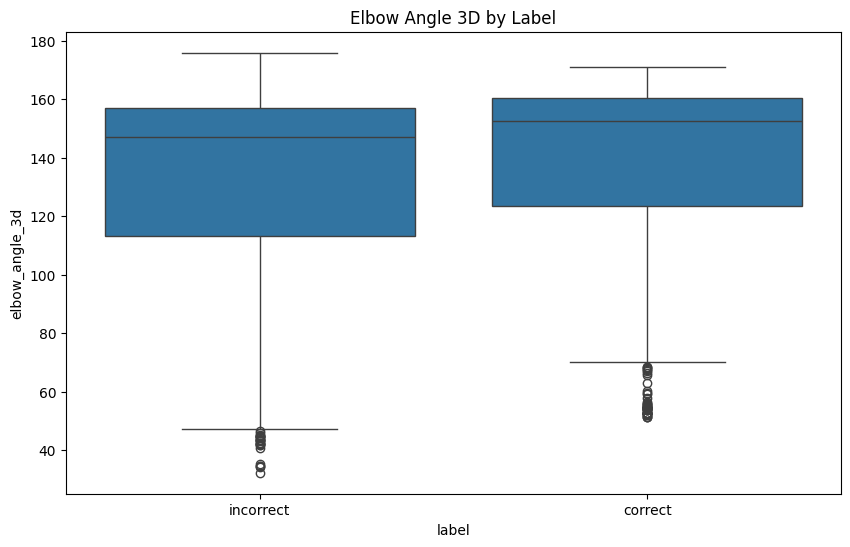

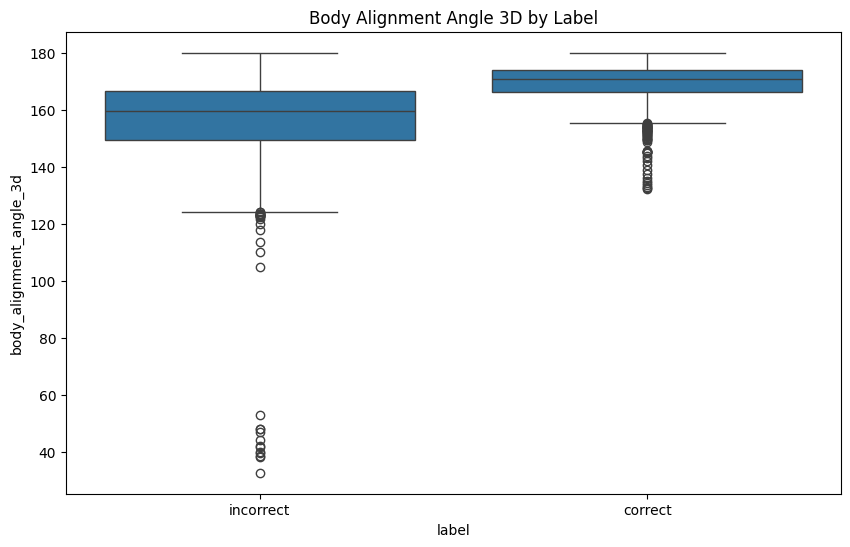

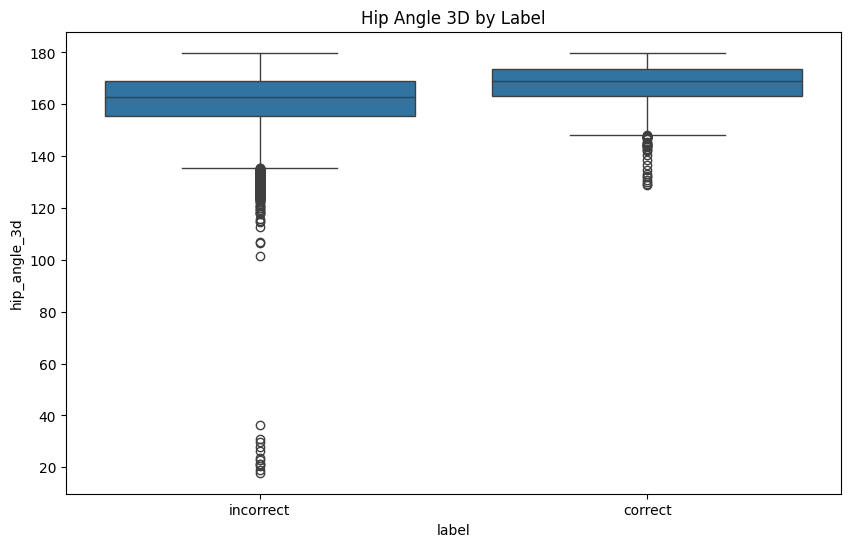

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=feature_df, x="label", y="elbow_angle_3d")
plt.title("Elbow Angle 3D by Label")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=feature_df, x="label", y="body_alignment_angle_3d")
plt.title("Body Alignment Angle 3D by Label")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=feature_df, x="label", y="hip_angle_3d")
plt.title("Hip Angle 3D by Label")
plt.show()

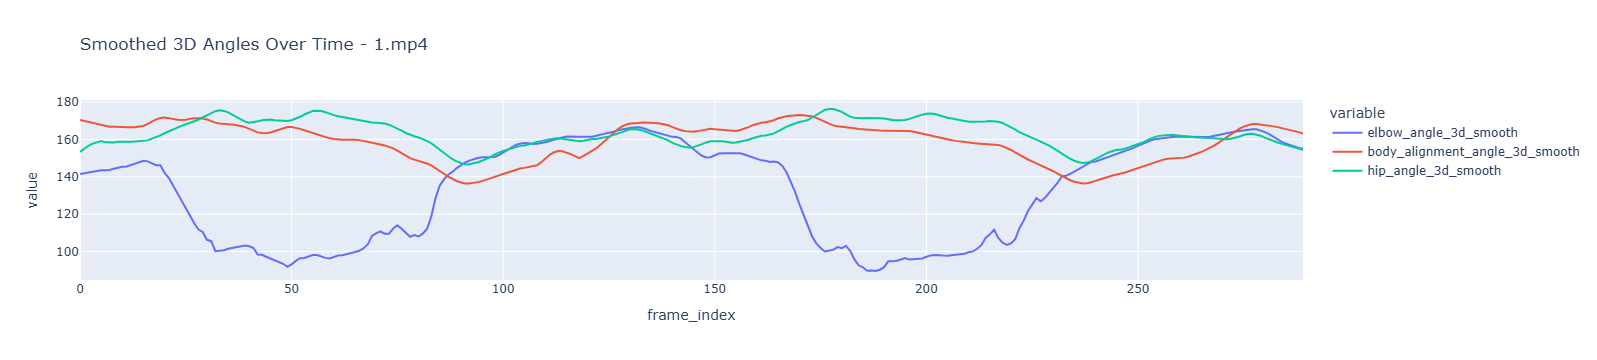

In [16]:
example_video = feature_df["video_name"].iloc[0]
example_df = feature_df[feature_df["video_name"] == example_video].copy()

fig = px.line(
    example_df,
    x="frame_index",
    y=[
        "elbow_angle_3d_smooth",
        "body_alignment_angle_3d_smooth",
        "hip_angle_3d_smooth"
    ],
    title=f"Smoothed 3D Angles Over Time - {example_video}"
)
fig.show()

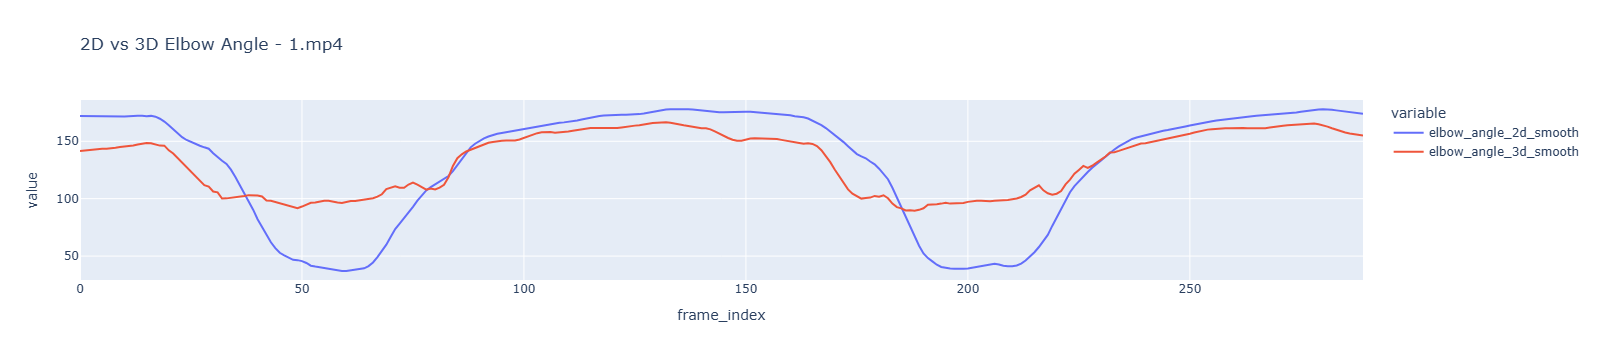

In [17]:
example_video = feature_df["video_name"].iloc[0]
example_df = feature_df[feature_df["video_name"] == example_video].copy()

fig = px.line(
    example_df,
    x="frame_index",
    y=["elbow_angle_2d_smooth", "elbow_angle_3d_smooth"],
    title=f"2D vs 3D Elbow Angle - {example_video}"
)
fig.show()

In [18]:
aggregation_dict = {
    "label": "first",
    "selected_side": lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0],
    
    "elbow_angle_2d_smooth": ["mean", "std", "min", "max"],
    "elbow_angle_3d_smooth": ["mean", "std", "min", "max"],
    
    "body_alignment_angle_2d_smooth": ["mean", "std", "min", "max"],
    "body_alignment_angle_3d_smooth": ["mean", "std", "min", "max"],
    
    "hip_angle_2d_smooth": ["mean", "std", "min", "max"],
    "hip_angle_3d_smooth": ["mean", "std", "min", "max"],
    
    "knee_angle_2d_smooth": ["mean", "std", "min", "max"],
    "knee_angle_3d_smooth": ["mean", "std", "min", "max"],
    
    "elbow_angle_3d_smooth_diff": ["mean", "std"],
    "body_alignment_angle_3d_smooth_diff": ["mean", "std"],
    "hip_angle_3d_smooth_diff": ["mean", "std"],
    
    "pose_detected": "mean"
}

video_level_df = feature_df.groupby("video_name").agg(aggregation_dict)
video_level_df.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in video_level_df.columns.values
]
video_level_df = video_level_df.reset_index()

print("Video-level dataset shape:", video_level_df.shape)
video_level_df.head()

Video-level dataset shape: (100, 42)


,video_name,label_first,selected_side_<lambda>,elbow_angle_2d_smooth_mean,elbow_angle_2d_smooth_std,elbow_angle_2d_smooth_min,elbow_angle_2d_smooth_max,elbow_angle_3d_smooth_mean,elbow_angle_3d_smooth_std,elbow_angle_3d_smooth_min,...,knee_angle_3d_smooth_std,knee_angle_3d_smooth_min,knee_angle_3d_smooth_max,elbow_angle_3d_smooth_diff_mean,elbow_angle_3d_smooth_diff_std,body_alignment_angle_3d_smooth_diff_mean,body_alignment_angle_3d_smooth_diff_std,hip_angle_3d_smooth_diff_mean,hip_angle_3d_smooth_diff_std,pose_detected_mean
0,1.mp4,incorrect,right,131.529385,50.035481,37.014255,178.079547,132.993026,26.328173,89.582356,...,4.188542,143.099334,161.204132,0.046671,1.939300,-0.024746,0.783435,0.003579,0.775566,1.0
1,10.mp4,incorrect,right,143.709620,47.922323,35.975715,180.049503,122.130830,29.776975,58.179325,...,6.751475,145.195764,168.336259,0.126513,3.271578,0.012559,0.735951,0.072174,1.253310,1.0
2,11.mp4,incorrect,right,124.318309,61.609328,6.362616,181.277948,117.440292,38.226489,56.695957,...,4.233679,142.208659,157.634884,0.041825,4.245996,0.014363,0.907820,-0.123670,1.163141,1.0
3,12.mp4,incorrect,right,140.166148,52.029299,12.468674,180.276857,121.826055,29.163012,63.313515,...,15.576582,103.575214,158.331799,-0.072913,4.102400,0.002196,0.866074,0.004506,1.151618,1.0
4,13.mp4,incorrect,right,116.396072,53.141496,13.799650,179.662436,111.174759,27.441589,60.737919,...,10.126725,123.498671,162.702132,-0.019197,3.960415,-0.037395,1.004668,-0.077426,0.950266,1.0


In [19]:
feature_df.to_csv(FEATURES_CSV_PATH, index=False)

VIDEO_LEVEL_FEATURES_CSV_PATH = PROCESSED_DIR / "pushup_video_level_features.csv"
video_level_df.to_csv(VIDEO_LEVEL_FEATURES_CSV_PATH, index=False)

print("Saved frame-level features to:", FEATURES_CSV_PATH)
print("Saved video-level features to:", VIDEO_LEVEL_FEATURES_CSV_PATH)

Saved frame-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\pushup_features.csv
Saved video-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\pushup_video_level_features.csv


In [20]:
print("Frame-level shape:", feature_df.shape)
print("Video-level shape:", video_level_df.shape)

print("\nFrame-level labels:")
print(feature_df["label"].value_counts())

print("\nVideo-level labels:")
print(video_level_df["label_first"].value_counts() if "label_first" in video_level_df.columns else "Check label column name.")

Frame-level shape: (10928, 173)
Video-level shape: (100, 42)

Frame-level labels:
label
incorrect    6425
correct      4503
Name: count, dtype: int64

Video-level labels:
label_first
incorrect    50
correct      50
Name: count, dtype: int64
